In [ ]:
import kagglehub
import os
import shutil

# Целевая переменная: Species 
cache_path = kagglehub.dataset_download("uciml/iris")

csv_filename = [f for f in os.listdir(cache_path) if f.endswith('.csv')][0]
source_file = os.path.join(cache_path, csv_filename)

local_file_name = "data.csv"
shutil.copy(source_file, local_file_name)

'data.csv'

In [316]:
import pandas as pd

df = pd.read_csv("data.csv")

df = df.drop('Id', axis=1)

print(df.head())

print(f"Размер: {df.shape}\n")

print(f"Типы данных:\n{df.dtypes}\n")

print(f"Пропуски в данных:\n{df.isnull().sum()}\n")

print(f"Распределение классов: ")
class_distribution = df['Species'].value_counts()
print(class_distribution)
print("Классы сбалансированы\n")

print(f"ДУбЛИКАТЫ:\n ")

dublicates = df.duplicated().sum()
print(f"Количество дубликатов: {dublicates}\n")
df = df.drop_duplicates()
dublicates_after = df.duplicated().sum()
print(f"Количество дубликатов после удаления: {dublicates_after}\n")

mapping = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
df['Encoded_Species'] = df['Species'].map(mapping)
print(df.head(5))

print(f"Размер датасета после обработки: {df.shape}")

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa
Размер: (150, 5)

Типы данных:
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Пропуски в данных:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Распределение классов: 
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
Классы сбалансированы

ДУбЛИКАТЫ:
 
Количество дубликатов: 3

Количество дубликатов после удаления: 0

   SepalLengthCm  SepalWidthCm  Peta

In [317]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np


df.info()

# Признаки
X = df.drop(['Species' , 'Encoded_Species'], axis=1)

#Ответы
y = df['Encoded_Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape}")

print(f"Размер тестовой выборки: {X_test.shape}")

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SepalLengthCm    147 non-null    float64
 1   SepalWidthCm     147 non-null    float64
 2   PetalLengthCm    147 non-null    float64
 3   PetalWidthCm     147 non-null    float64
 4   Species          147 non-null    object 
 5   Encoded_Species  147 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 8.0+ KB
Размер обучающей выборки: (117, 4)
Размер тестовой выборки: (30, 4)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': list(range(1,31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1 
)

grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Точность на кросс-валидации (средняя): {grid_search.best_score_:.4f}")

# Проверка на тесте
final_acc = grid_search.best_estimator_.score(X_test, y_test)
print(f"Точность на тестовой выборке: {final_acc:.4f}")


Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Точность на кросс-валидации (средняя): 0.9830
Точность на тестовой выборке: 0.9333


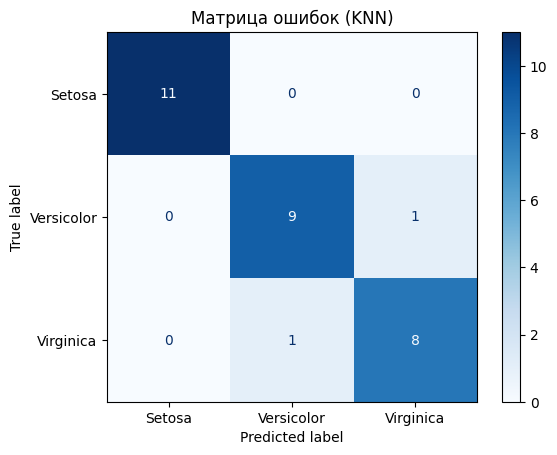

In [319]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = grid_search.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Setosa', 'Versicolor', 'Virginica'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Матрица ошибок (KNN)')
plt.show()

Выводы:

    1. Соседи: при малом количестве модель слишком чувствительна к аномалиям в цветах. Более большое число позволяет это сгладить.

    2. Евклидово расстояние хорошо сработало тк одинаковую единицу измерения признаков и сопоставимый масштаб.
   
    3. Как видно из матрицы ошибок, цвета Versicolor и Virginica очень похожи. Это значит, что любой шум в этой зоне может привести к ошибке.
   
    4. Маштабирование важно для knn, потому что он ищет близжайшие точки. Если один параметр больше другого в сотни раз, то он будет считаться более важным для knn, хотя первый параметр менее важный, чем второй. Также компьютеру легче работать с числами,приблеженными к нулю. В нашем случае ширина бы вносила меньше вклада, чем длина лепестка.
   
    5. KNN хорош для маленьких датасетов.

Почему нельзя подбирать параметры на тестовой выборке? Потому что подбирая параметры на тестовой выборке мы теряем объективность модели на данных, которые она еще не видела. 